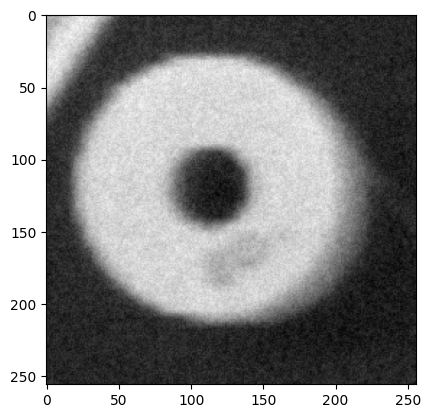

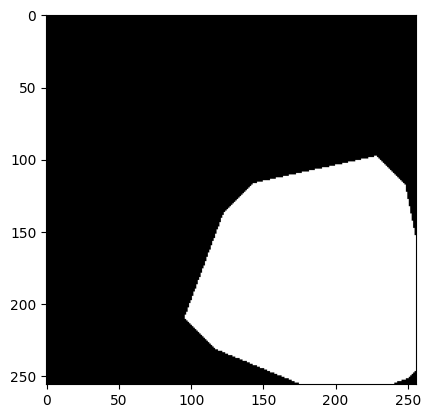

In [1]:
import cv2
import matplotlib.pyplot as plt


rondelle = cv2.imread("RONDELLE.png", cv2.IMREAD_ANYDEPTH)
spot = cv2.imread("SPOT.png", cv2.IMREAD_ANYDEPTH)

plt.imshow(rondelle, cmap='gray')
plt.show()

plt.imshow(spot, cmap='gray')
plt.show()

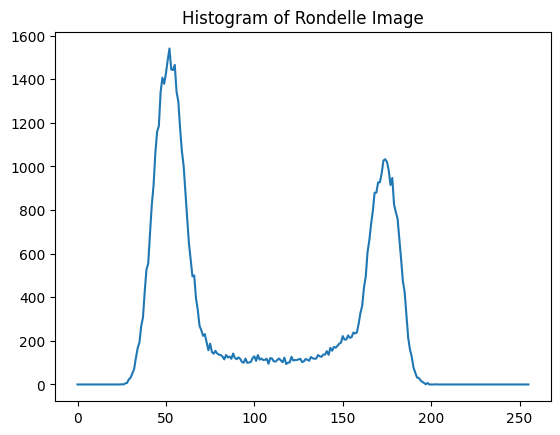

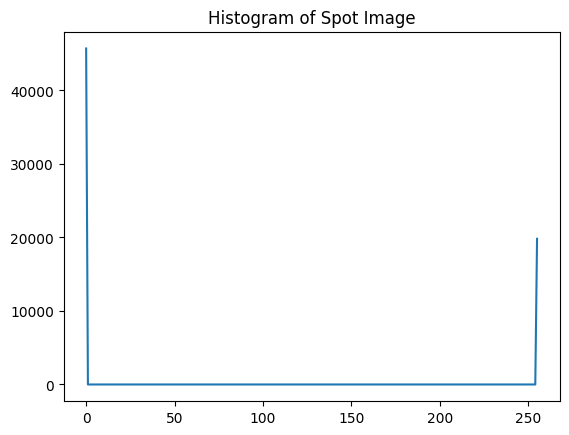

In [2]:
hist_rondelle = cv2.calcHist([rondelle],[0],None,[256],[0,256])
plt.plot(hist_rondelle)
plt.title('Histogram of Rondelle Image')
plt.show()
hist_spot = cv2.calcHist([spot],[0],None,[256],[0,256])
plt.plot(hist_spot)
plt.title('Histogram of Spot Image')
plt.show()

El histograma muestra de Rondelle evidencia que la imagen cuenta con varias tonalidades de grises desde 25 hasta 200. Lambién muestra una predominancia de los tonos al rededor de 25 y de 75 (llegando a un pico cercano a 1700 y 1100 respectivamente) y una distribución similar entre los tonos hallados desde 75 hasta 150 (siendo las ocurrencias cercanas a 200). 

Por otro lado, el histograma de Spot evidencia que existen únicamente dos colores: blanco y negro. En cuanto al negro, se hallan al rededor de 50 mil pixeles de ese color y los restantes 20 mil son de color blanco. No hay demás tonos de grises.

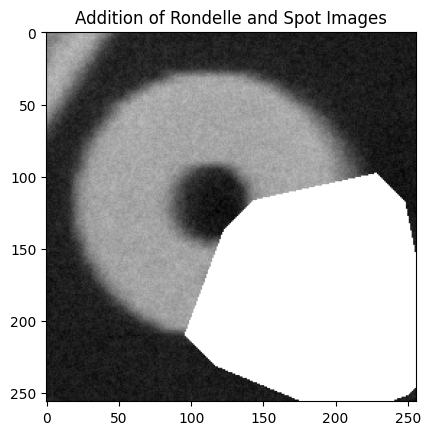

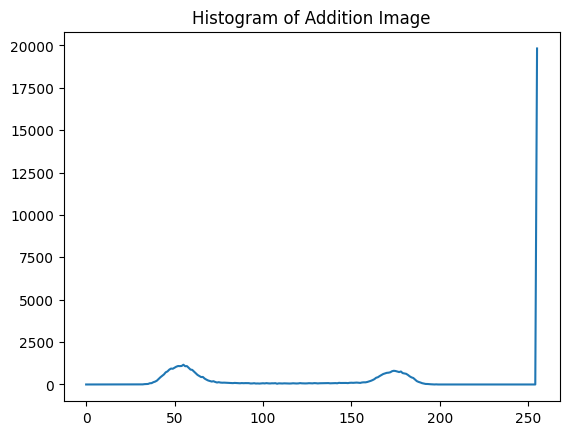

In [3]:
addition = cv2.add(rondelle, spot)
plt.imshow(addition, cmap='gray')
plt.title('Addition of Rondelle and Spot Images')
plt.show()

hist_addition = cv2.calcHist([addition],[0],None,[256],[0,256])
plt.plot(hist_addition)
plt.title('Histogram of Addition Image')
plt.show()

Al hacer la adición se agregó la mancha blanca de Spot a la imagen de Rondelle. El resto de Rondelle se mantiene intacto ya que no hubo cambio de color. Esto se evidencia en el histograma en cuanto a que ahora hay una gran cantidad de ocurrencias en la intensidad blanca. Sin embargo, es posible seguir viendo el patrón inicial de los dos picos que generaba Rondelle en un inicio, solo que se ve pequeño en comparación con los puntos blancos.

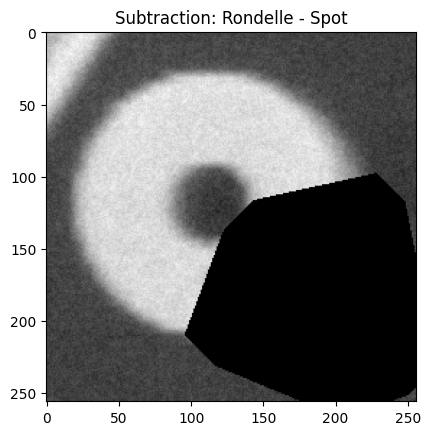

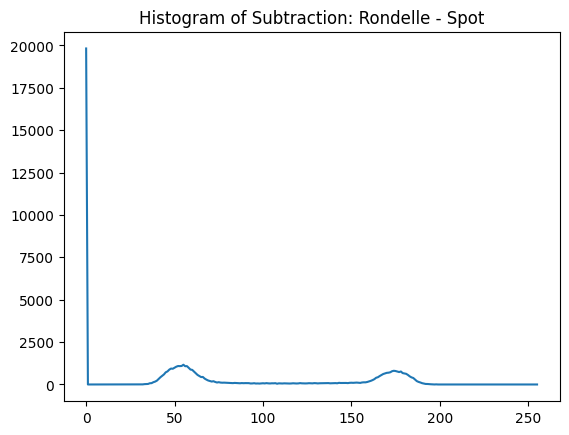

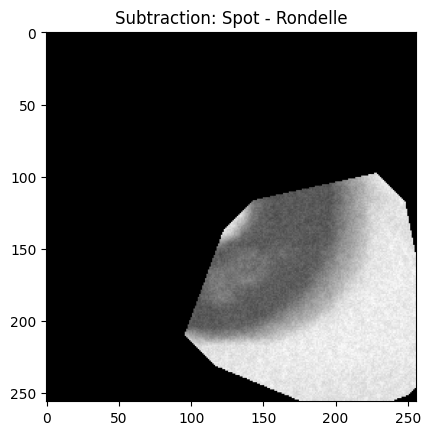

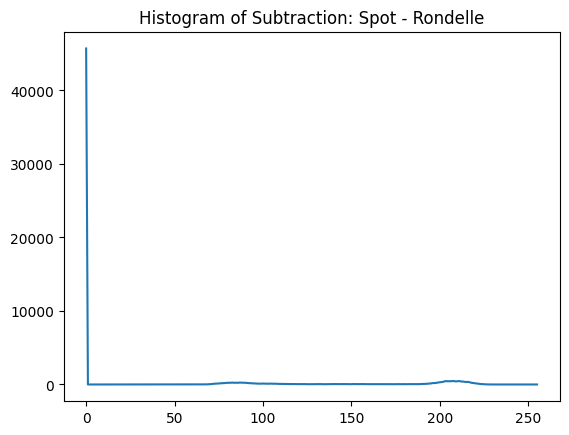

In [4]:
subtraction_1 = cv2.subtract(rondelle, spot)
plt.imshow(subtraction_1, cmap='gray')
plt.title('Subtraction: Rondelle - Spot')
plt.show()

hist_subtraction_1 = cv2.calcHist([subtraction_1],[0],None,[256],[0,256])
plt.plot(hist_subtraction_1)
plt.title('Histogram of Subtraction: Rondelle - Spot')
plt.show()

subtraction_2 = cv2.subtract(spot, rondelle)
plt.imshow(subtraction_2, cmap='gray')
plt.title('Subtraction: Spot - Rondelle')
plt.show()

hist_subtraction_2 = cv2.calcHist([subtraction_2],[0],None,[256],[0,256])
plt.plot(hist_subtraction_2)
plt.title('Histogram of Subtraction: Spot - Rondelle')
plt.show()

1. Rondelle - Spot: Se puede evidenciar que la resta de spot afecta unicamente en el espacio donde habia una mancha blanca. Esto se debe a que el negro es ausencia de Bits por lo que no disminuye nada, a diferencia del blanco que implica la totalidad, lo cual lleva a disminuir al máximo el resultado de la resta. Así, ahora Rondelle tiene una mancha negra donde antes estaba la mancha de Spot. Esto se evidencia en el histograma en cuanto ahora la cantidad de ocurrencias negras aumenta, manteniendo el patrón caracteristico de Rondelle.
2. Spot-Rondelle: Spot cuenta con un fondo negro, por lo que este fondo se mantiene ya que el color no se puede volver más oscuro. Sin embargo, en donde estaba la mancha blanca ocurre un fenomeno curioso y es que los tonos se invierten. Esto se debe a que, gracias a la resta, ahora se recorren las intensidades de grises desde los blancos disminuyendo el tono blanco puro inicial. Esto se evidencia en el histograma en cuanto la gran mayoría de las ocurrencias son del color negro y existe el mismo patrón de Rondelle de forma invertida y en menor magnitud.

En definitiva, el orden de los operandos afecta al momento de determinar qué se le quita a quien. Por ejemplo, si la primera imagen es la que tiene los negros, esta, a pesar de la resta, las zonas negras no se veran afectadas ya que no pueden disminuir más. Por otro lado, si es la que está siendo restada esta no se afectará la otra imagen ya que nada se le puede restar. Otro aspecto a destacar es la resta con el blanco que cuando está restando como en el caso 1 convierte la zona en un negro absoluto mientras que cuando es a la que se le resta lo que hace es invertir el color de lo que se le está restando.

Conociendo únicamente los histogramas de las imágenes operandos (y no las imágenes mismas), ¿es posible prever el histograma de la imagen que se obtendrá con una operación aritmética sobre estas imágenes operandos? ¿Por qué?

No, no es posible prever con exactitud el histograma de la imagen sabiendo únicamente los histogramas de las imágenes de los operandos y no las imágenes mismas. Esto se debe a que si bien sabemos el número de ocurrencias en cada intensidad, no sabemos su distribución, por lo que no podemos saber la forma en la que va a variar cada pixel luego de la operaciones ya que no sabemos su tonalidad especifica. Por ejemplo, como ya vimos no es lo mismo restarle blanco a un pixel negro que a un pixel blanco, pues mientras el negro seguirá siendo negro, el blanco dejará de ser blanco lo cual cambiaria el histograma resultante de la operación. 